In [1]:
# !pip install opencv-python imgbeddings psycopg2-binary

In [2]:
import cv2
import matplotlib.pyplot as plt
import glob
import os
import math

In [3]:
# algorithm from github and loading it
alg = 'Biometry/Face-Recognition/haarcascade_frontalface_default.xml'
haar_cascade = cv2.CascadeClassifier(alg)

file_name = 'modernfamily.jpg'
img = cv2.imread(file_name)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# detecting faces from the picture
faces = haar_cascade.detectMultiScale(gray, scaleFactor=1.05, minNeighbors=5, minSize=(100, 100))

i=0
# for each face detected
for x, y, w, h in faces:
    cropped_image = gray[y : y + h, x : x + w]
    # do not forget about creating folder
    target_file_name = 'Biometry/Face-Recognition/stored_faces/' + str(i) + '.jpg'
    cv2.imwrite(target_file_name, cropped_image)
    i = i + 1;

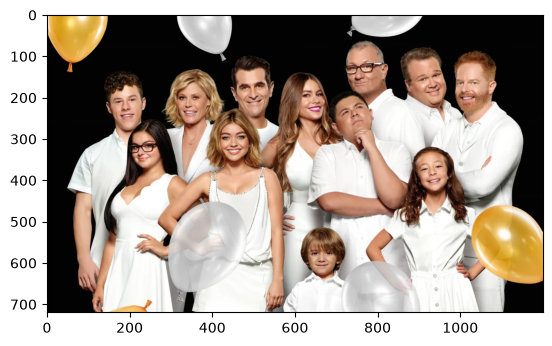

In [4]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

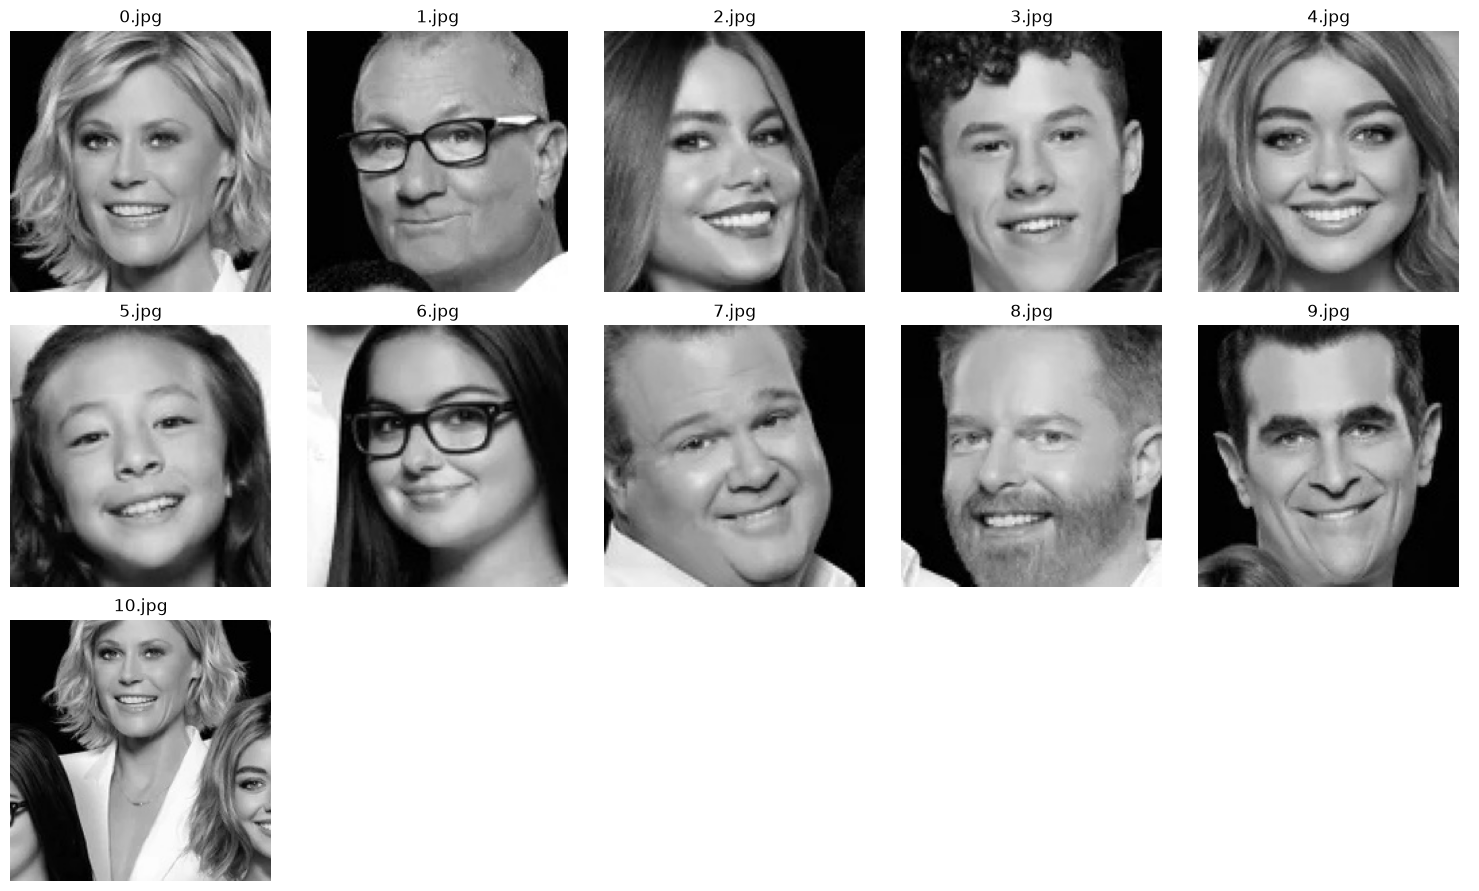

In [5]:
stored_faces_dir = 'Face-Recognition/stored_faces'
face_files = sorted(
    glob.glob(os.path.join(stored_faces_dir, '*.jpg')),
    key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
)

n = len(face_files)
cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

for ax, face_file in zip(axes.flat, face_files):
    face_img = cv2.imread(face_file)
    ax.imshow(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(face_file))
    ax.axis('off')

# hide any unused subplot slots
for ax in axes.flat[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# importing the required libraries
import warnings
from tqdm.std import TqdmWarning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=TqdmWarning)

import numpy as np
from imgbeddings import imgbeddings
from PIL import Image
import psycopg2
import os

# connecting to the database - replace the SERVICE URI with the service URI
conn = psycopg2.connect("replace the SERVICE URI with the service URI")

for filename in os.listdir("stored_faces"):
    if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
        continue
    img = Image.open("stored_faces/"+ filename)
    # loading the `imgbeddings`
    ibed = imgbeddings()
    # calculating the embeddings
    embedding = ibed.to_embeddings(img)
    cur = conn.cursor()
    cur.execute(
        "INSERT INTO pictures values (%s,%s) ON CONFLICT (picture) DO UPDATE SET embedding = EXCLUDED.embedding",
        (filename, embedding[0].tolist())
    )
    print(filename)
conn.commit()

In [7]:
# image paths to test against the stored faces
alex = "alex.jpg"
claire = 'claire.jpg'
phil = 'phil.jpg'
luke = 'luke.jpg'

In [8]:
def find_match(image_path):
    img = Image.open(image_path)
    ibed = imgbeddings()
    embedding = ibed.to_embeddings(img)
    string_representation = "["+ ",".join(str(x) for x in embedding[0].tolist()) +"]"
    cur = conn.cursor()
    # next line does all the magic, basically what it does it will all the pictures that we store that are similar to the one we are uploading
    cur.execute("SELECT * FROM pictures ORDER BY embedding <-> %s LIMIT 1;", (string_representation,))
    rows = cur.fetchall()
    cur.close()
    return "stored_faces/" + rows[0][0]

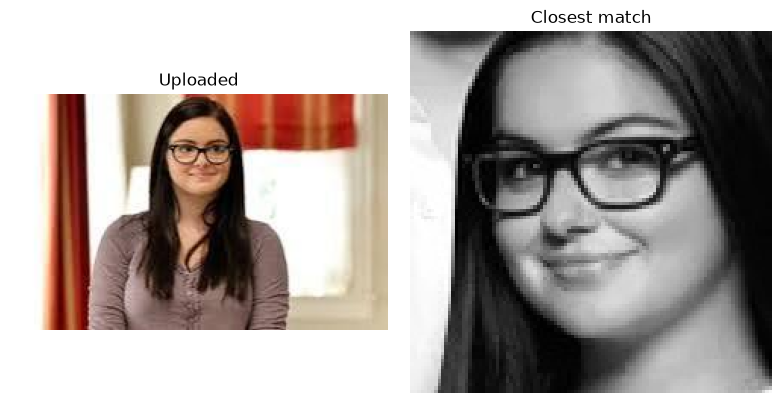

In [9]:
match_file = find_match(alex)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Image.open(alex))
axes[0].set_title("Uploaded")
axes[0].axis("off")
axes[1].imshow(Image.open(match_file), cmap="gray")
axes[1].set_title("Closest match")
axes[1].axis("off")
plt.tight_layout()
plt.show()

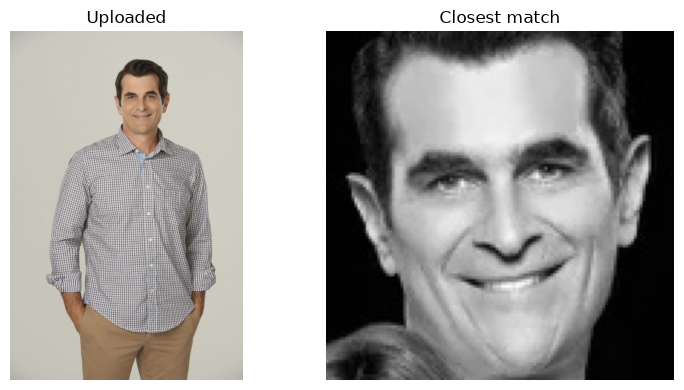

In [15]:
match_file = find_match(phil)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Image.open(phil))
axes[0].set_title("Uploaded")
axes[0].axis("off")
axes[1].imshow(Image.open(match_file), cmap="gray")
axes[1].set_title("Closest match")
axes[1].axis("off")
plt.tight_layout()
plt.show()

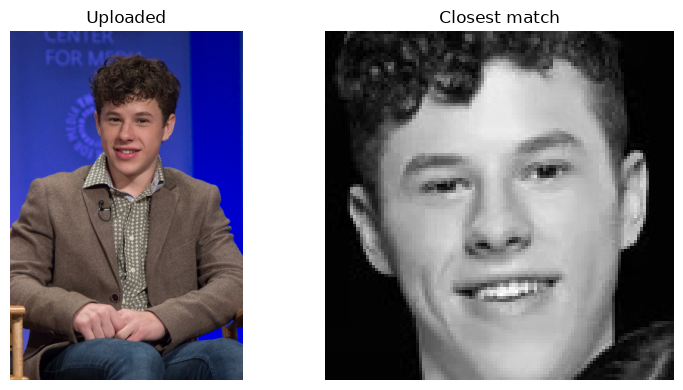

In [14]:
match_file = find_match(luke)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Image.open(luke))
axes[0].set_title("Uploaded")
axes[0].axis("off")
axes[1].imshow(Image.open(match_file), cmap="gray")
axes[1].set_title("Closest match")
axes[1].axis("off")
plt.tight_layout()
plt.show()

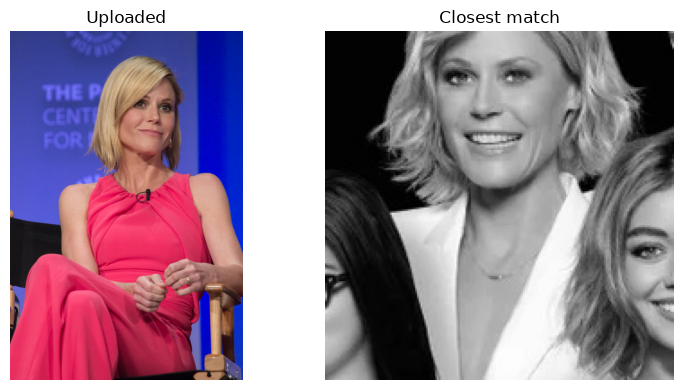

In [12]:
match_file = find_match(claire)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Image.open(claire))
axes[0].set_title("Uploaded")
axes[0].axis("off")
axes[1].imshow(Image.open(match_file), cmap="gray")
axes[1].set_title("Closest match")
axes[1].axis("off")
plt.tight_layout()
plt.show()